In [25]:
import os, glob, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

torch.manual_seed(0); np.random.seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

plt.rcParams.update({
    "axes.titlesize":  14,
    "axes.labelsize":  13,
    "legend.fontsize": 11,
})

device: cpu


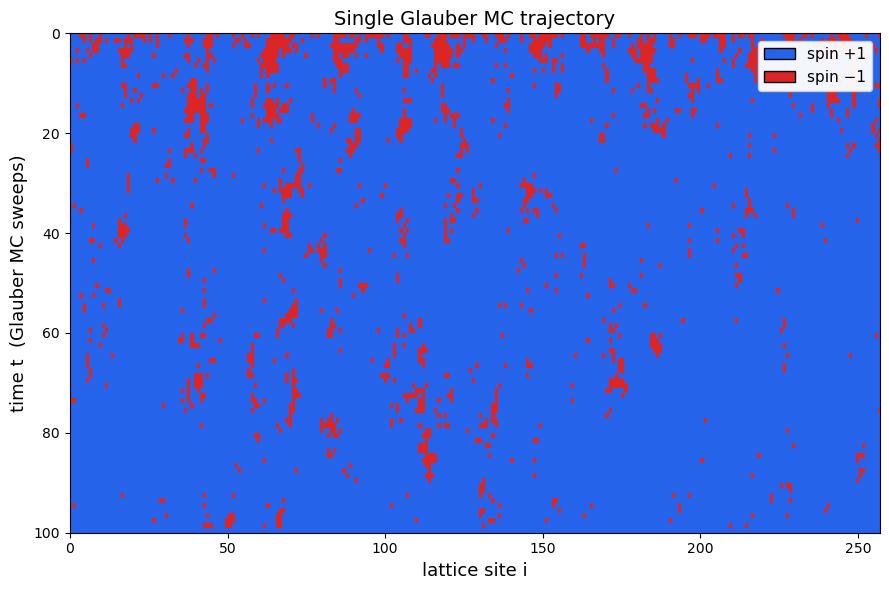

In [26]:
DATA_DIR  = 'data_grid'
COND_FILE = 'cond_026.npz'
RUN_IDX = 0
N_SHOW = 257

d  = np.load(f'{DATA_DIR}/{COND_FILE}')
tr = d['trajectories']
p  = tr[RUN_IDX].astype(np.float32) / int(d['num_points'])
spins = np.where(p >= 0.5, 1, -1)[:, :N_SHOW]
beta, h, J = float(d['beta']), float(d['h']), float(d['J'])

cmap = ListedColormap(['#dc2626', '#2563eb'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(spins, cmap=cmap, aspect='auto',
          extent=[0, N_SHOW, float(d['total_time']), 0],
          interpolation='nearest', vmin=-1, vmax=1)
ax.set_xlabel(f'lattice site i')
ax.set_ylabel('time t  (Glauber MC sweeps)')
ax.set_title(f'Single Glauber MC trajectory')

ax.legend(handles=[
    Patch(facecolor='#2563eb', edgecolor='black', label='spin +1'),
    Patch(facecolor='#dc2626', edgecolor='black', label='spin −1'),
], loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

In [27]:
DATA_DIR = 'data_grid'
DATA_FILE = 'cond_046.npz'
TOTAL_TIME = 100.0
T_KEEP = 99

d  = np.load(os.path.join(DATA_DIR, DATA_FILE))
tr = d['trajectories'][:, :T_KEEP, :]
p  = tr.astype(np.float32) / int(d['num_points'])

beta_true = float(d['beta'])
h_true = float(d['h'])
J_true = float(d['J'])

spins_all = (2.0 * p - 1.0).astype(np.float32)
m_per_run = (2.0 * p.mean(axis=2) - 1.0).astype(np.float32)
m_bar = m_per_run.mean(axis=0)
nn_prod = spins_all * np.roll(spins_all, -1, axis=2)
nn2_prod = spins_all * np.roll(spins_all, -2, axis=2)
eps_bar = nn_prod.mean(axis=2).mean(axis=0).astype(np.float32)
eps2_bar = nn2_prod.mean(axis=2).mean(axis=0).astype(np.float32)

t_grid = np.linspace(0.0, TOTAL_TIME, T_KEEP + 1, endpoint=False)[:T_KEEP].astype(np.float32)

def glauber_constants(beta, h, J):
    f_p2 = np.tanh(beta * (h + 2*J))
    f_0  = np.tanh(beta * h)
    f_m2 = np.tanh(beta * (h - 2*J))
    a0 = 0.5 * (f_p2 + 2.0 * f_0 + f_m2)
    a1 = 0.5 * (f_p2 - f_m2)
    a2 = 0.5 * (f_p2 - 2.0 * f_0 + f_m2)
    return float(a0), float(a1), float(a2)

a0_true, a1_true, a2_true = glauber_constants(beta_true, h_true, J_true)
print(f'(β, h, J) = ({beta_true:.4f}, {h_true:.4f}, {J_true:.4f})')
print(f'analytical (a₀, a₁, a₂) = ({a0_true:+.4f}, {a1_true:+.4f}, {a2_true:+.4f})')

(β, h, J) = (0.9000, 0.0575, 1.1667)
analytical (a₀, a₁, a₂) = (+0.0547, +0.9703, -0.0487)


In [28]:
def _make_mlp(hidden=128, depth=4, n_out=1):
    layers = [nn.Linear(1, hidden), nn.Softplus()]
    for _ in range(depth - 1):
        layers += [nn.Linear(hidden, hidden), nn.Softplus()]
    layers += [nn.Linear(hidden, n_out)]
    return nn.Sequential(*layers)

def _scalar_init(value, scale):
    v = max(min(float(value) / scale, 0.99), -0.99)
    return torch.tensor(np.arctanh(v), dtype=torch.float32)

class PINN_m(nn.Module):
    def __init__(self, total_time=TOTAL_TIME):
        super().__init__()
        self.total_time = float(total_time)
        self.net = _make_mlp(hidden=128, depth=4, n_out=1)
        self.a0_raw = nn.Parameter(_scalar_init(float(torch.empty(1).uniform_(-0.5, 0.5).item()), 2.0))
        self.a1_raw = nn.Parameter(_scalar_init(float(torch.empty(1).uniform_(-0.3, 0.3).item()), 1.0))
        self.a2_raw = nn.Parameter(_scalar_init(float(torch.empty(1).uniform_(-0.5, 0.5).item()), 2.0))
    @property
    def a0(self): return 2.0 * torch.tanh(self.a0_raw)
    @property
    def a1(self): return torch.tanh(self.a1_raw)
    @property
    def a2(self): return 2.0 * torch.tanh(self.a2_raw)
    def forward(self, t):
        return torch.tanh(self.net(t / self.total_time))

class PINN_eps2(nn.Module):
    def __init__(self, total_time=TOTAL_TIME):
        super().__init__()
        self.total_time = float(total_time)
        self.net = _make_mlp(hidden=128, depth=4, n_out=1)
    def forward(self, t):
        return torch.tanh(self.net(t / self.total_time))

class Standard_channel(nn.Module):
    def __init__(self, total_time=TOTAL_TIME):
        super().__init__()
        self.total_time = float(total_time)
        self.net = _make_mlp(hidden=128, depth=4, n_out=1)
    def forward(self, t):
        return torch.tanh(self.net(t / self.total_time))

def time_derivative(y, t):
    return torch.autograd.grad(y, t, grad_outputs=torch.ones_like(y),
                               create_graph=True, retain_graph=True)[0]

In [29]:
EPOCHS_ADAM = 4000
LR = 1e-3
LBFGS_STEPS = 300
N_COLLOC = 200

torch.manual_seed(0)
m_model = PINN_m().to(device)
t_t = torch.tensor(t_grid, dtype=torch.float32, device=device).view(-1, 1)
m_t = torch.tensor(m_bar,  dtype=torch.float32, device=device).view(-1, 1)

m_hist = {'data': [], 'phys': [], 'a0': [], 'a1': [], 'a2': []}

def m_phys_loss(t_c):
    m_c = m_model(t_c)
    m_dot = time_derivative(m_c, t_c)
    res = m_dot + (1.0 - m_model.a1) * m_c - 0.5 * m_model.a0 - 0.5 * m_model.a2 * m_c ** 2
    return torch.mean(res ** 2)

def log_step(L_d, L_p):
    m_hist['data'].append(L_d)
    m_hist['phys'].append(L_p)
    m_hist['a0'].append(m_model.a0.item())
    m_hist['a1'].append(m_model.a1.item())
    m_hist['a2'].append(m_model.a2.item())

opt = torch.optim.Adam(m_model.parameters(), lr=LR)
print('PINN-m training (4000 Adam + 300 LBFGS)…')
for ep in range(EPOCHS_ADAM):
    opt.zero_grad()
    L_d = torch.mean((m_model(t_t) - m_t) ** 2)
    t_c = (torch.rand(N_COLLOC, 1, device=device) * TOTAL_TIME).requires_grad_(True)
    L_p = m_phys_loss(t_c)
    (L_d + L_p).backward()
    opt.step()
    log_step(L_d.item(), L_p.item())
    if ep % 1000 == 0 or ep == EPOCHS_ADAM - 1:
        print(f'  [Adam] ep {ep:5d}   L_d={L_d.item():.3e}   L_p={L_p.item():.3e}')

opt_l = torch.optim.LBFGS(m_model.parameters(), lr=1.0, max_iter=25,
    history_size=100, line_search_fn='strong_wolfe',
    tolerance_grad=1e-12, tolerance_change=1e-15)
t_c_fixed = torch.linspace(0.0, TOTAL_TIME, 2000, device=device).view(-1, 1)
t_c_fixed.requires_grad_(True)
last = {'L_d': None, 'L_p': None}
def cl_m():
    opt_l.zero_grad()
    L_d = torch.mean((m_model(t_t) - m_t) ** 2)
    L_p = m_phys_loss(t_c_fixed)
    L = L_d + L_p
    L.backward()
    last['L_d'] = L_d.item(); last['L_p'] = L_p.item()
    return L
for k in range(LBFGS_STEPS):
    opt_l.step(cl_m)
    log_step(last['L_d'], last['L_p'])
    if k % 50 == 0 or k == LBFGS_STEPS - 1:
        print(f'  [LBFGS] step {k:4d}  L_d={last["L_d"]:.3e}   L_p={last["L_p"]:.3e}')

with torch.no_grad():
    m_hat = m_model(t_t).cpu().numpy().squeeze()
a0_M, a1_M, a2_M = m_model.a0.item(), m_model.a1.item(), m_model.a2.item()
print(f'\nPINN-m recovered (a₀, a₁, a₂) = ({a0_M:+.4f}, {a1_M:+.4f}, {a2_M:+.4f})')
print(f'analytical truth = ({a0_true:+.4f}, {a1_true:+.4f}, {a2_true:+.4f})')

PINN-m training (4000 Adam + 300 LBFGS)…
  [Adam] ep     0   L_d=1.940e-01   L_p=2.442e-04
  [Adam] ep  1000   L_d=1.433e-04   L_p=8.010e-04
  [Adam] ep  2000   L_d=4.856e-05   L_p=3.331e-04
  [Adam] ep  3000   L_d=3.510e-05   L_p=5.366e-05
  [Adam] ep  3999   L_d=3.000e-05   L_p=2.740e-05
  [LBFGS] step    0  L_d=4.831e-06   L_p=2.788e-05
  [LBFGS] step   50  L_d=2.539e-06   L_p=1.833e-08
  [LBFGS] step  100  L_d=2.539e-06   L_p=1.833e-08
  [LBFGS] step  150  L_d=2.539e-06   L_p=1.833e-08
  [LBFGS] step  200  L_d=2.539e-06   L_p=1.833e-08
  [LBFGS] step  250  L_d=2.539e-06   L_p=1.833e-08
  [LBFGS] step  299  L_d=2.539e-06   L_p=1.833e-08

PINN-m recovered (a₀, a₁, a₂) = (+0.0367, +0.9353, +0.0899)
analytical truth = (+0.0547, +0.9703, -0.0487)


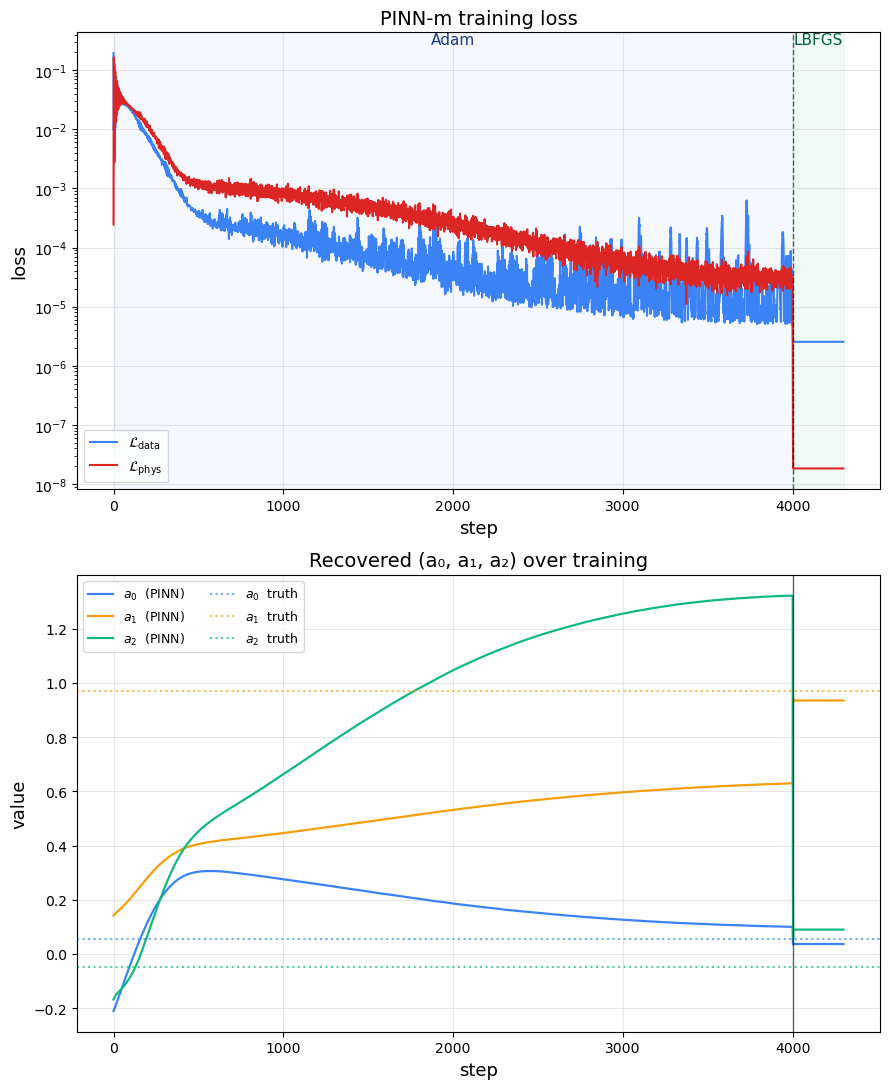

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(9, 11))

ax = axes[0]
n_total = len(m_hist['data'])
ax.plot(m_hist['data'], color='#3b82f6', lw=1.5, label=r'$\mathcal{L}_{\rm data}$')
ax.plot(m_hist['phys'], color='#dc2626', lw=1.5, label=r'$\mathcal{L}_{\rm phys}$')
ax.axvspan(0, EPOCHS_ADAM,        alpha=0.05, color='#3b82f6')
ax.axvspan(EPOCHS_ADAM, n_total,  alpha=0.06, color='#10b981')
ax.axvline(EPOCHS_ADAM, color='black', ls='--', lw=1, alpha=0.6)
ax.text(EPOCHS_ADAM / 2, 1.0, 'Adam', ha='center', va='top', fontsize=11,
        color='#1e3a8a', transform=ax.get_xaxis_transform())
ax.text((EPOCHS_ADAM + n_total) / 2, 1.0, 'LBFGS', ha='center', va='top',
        fontsize=11, color='#065f46', transform=ax.get_xaxis_transform())
ax.set_yscale('log'); ax.set_xlabel('step'); ax.set_ylabel('loss')
ax.set_title('PINN-m training loss')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(m_hist['a0'], color='#3b82f6', lw=1.6, label='$a_0$  (PINN)')
ax.plot(m_hist['a1'], color='#f59e0b', lw=1.6, label='$a_1$  (PINN)')
ax.plot(m_hist['a2'], color='#10b981', lw=1.6, label='$a_2$  (PINN)')
ax.axhline(a0_true, color='#3b82f6', ls=':', lw=1.5, alpha=0.7, label='$a_0$  truth')
ax.axhline(a1_true, color='#f59e0b', ls=':', lw=1.5, alpha=0.7, label='$a_1$  truth')
ax.axhline(a2_true, color='#10b981', ls=':', lw=1.5, alpha=0.7, label='$a_2$  truth')
ax.axvline(EPOCHS_ADAM, color='black', ls='-', lw=1, alpha=0.6)
ax.set_xlabel('step'); ax.set_ylabel('value')
ax.set_title('Recovered (a₀, a₁, a₂) over training')
ax.legend(fontsize=9, loc='best', ncol=2); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

In [31]:
torch.manual_seed(0)
e2_model = PINN_eps2().to(device)
e2_t = torch.tensor(eps2_bar, dtype=torch.float32, device=device).view(-1, 1)

opt = torch.optim.Adam(e2_model.parameters(), lr=LR)
for ep in range(EPOCHS_ADAM):
    opt.zero_grad()
    L = torch.mean((e2_model(t_t) - e2_t) ** 2)
    L.backward(); opt.step()

with torch.no_grad():
    e2_hat = e2_model(t_t).cpu().numpy().squeeze()
print(f'PINN-ε₂ trained:  ε̂₂ MSE vs MC = {float(np.mean((e2_hat - eps2_bar)**2)):.3e}')

PINN-ε₂ trained:  ε̂₂ MSE vs MC = 3.256e-07


In [32]:
torch.manual_seed(0)
v_m = Standard_channel().to(device)
v_e = Standard_channel().to(device)
v_e2 = Standard_channel().to(device)

e_t = torch.tensor(eps_bar, dtype=torch.float32, device=device).view(-1, 1)

def fit_standard(model, target_t):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    for ep in range(EPOCHS_ADAM):
        opt.zero_grad()
        L = torch.mean((model(t_t) - target_t) ** 2)
        L.backward(); opt.step()
    with torch.no_grad():
        return model(t_t).cpu().numpy().squeeze()

print('Training three Standard NN baselines (m, ε, ε₂)…')
m_v_arr = fit_standard(v_m,  m_t)
e_v_arr = fit_standard(v_e,  e_t)
e2_v_arr = fit_standard(v_e2, e2_t)

print(f'\nStandard-m: m̂  MSE = {float(np.mean((m_v_arr  - m_bar)**2)):.3e}')
print(f'Standard-ε: ε̂  MSE = {float(np.mean((e_v_arr  - eps_bar)**2)):.3e}')
print(f'Standard-ε₂: ε̂₂ MSE = {float(np.mean((e2_v_arr - eps2_bar)**2)):.3e}')

Training three Standard NN baselines (m, ε, ε₂)…

Standard-m: m̂  MSE = 2.912e-06
Standard-ε: ε̂  MSE = 9.011e-07
Standard-ε₂: ε̂₂ MSE = 2.838e-04


In [33]:
e_pinn_arr = m_hat ** 2
mse_e_pinn = float(np.mean((e_pinn_arr - eps_bar) ** 2))

print(f'ε derived from m̂²: MSE vs MC = {mse_e_pinn:.3e}')
print(f'(compare: ε̄ vs m̄² gives MSE = {float(np.mean((m_bar**2 - eps_bar)**2)):.3e})')

err_pinn = e_pinn_arr - eps_bar
print(f'RMSE = {np.sqrt(np.mean(err_pinn**2)):.3e}')
print(f'mean error = {np.mean(np.abs(err_pinn)):.3e}')
print(f'max error = {np.max(np.abs(err_pinn)):.3e}')

ε derived from m̂²: MSE vs MC = 2.774e-05
(compare: ε̄ vs m̄² gives MSE = 2.741e-05)
RMSE = 5.267e-03
mean error = 5.208e-03
max error = 6.549e-03


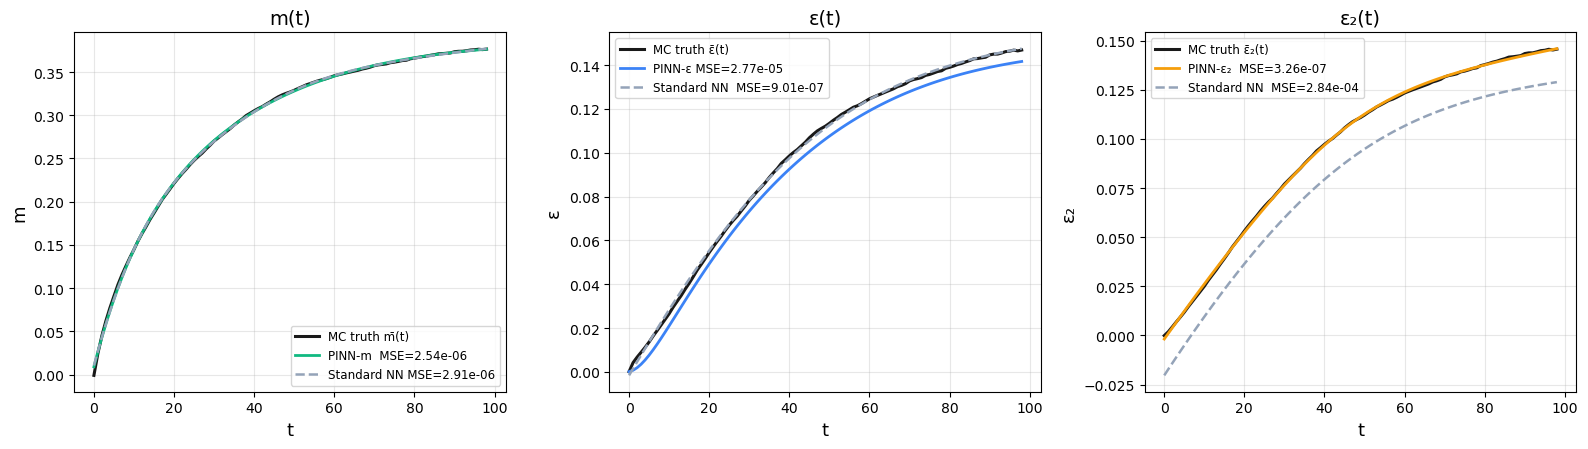

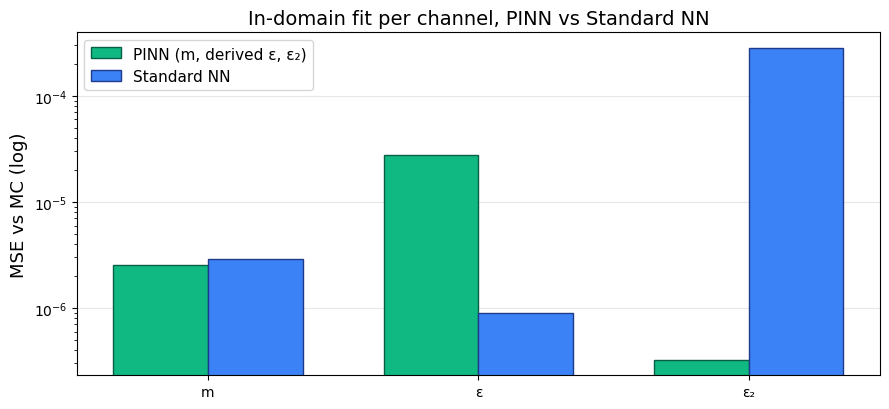

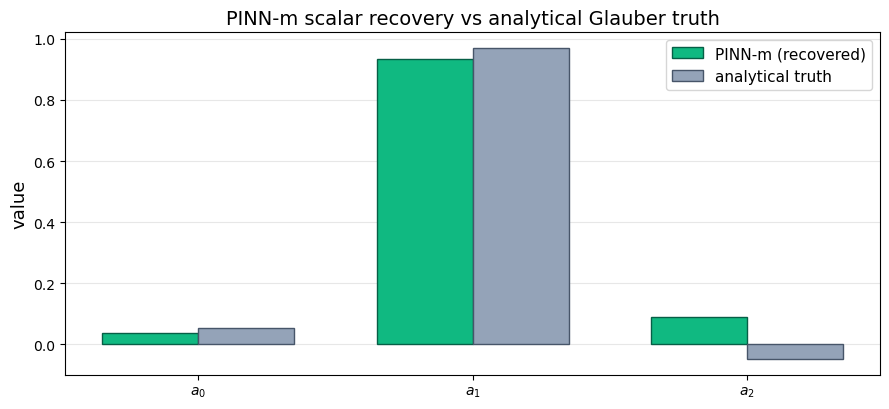

PINN-m  (a₀, a₁, a₂) = (+0.0367, +0.9353, +0.0899)
truth = (+0.0547, +0.9703, -0.0487)
errors |Δ| = (1.800e-02, 3.499e-02, 1.386e-01)


In [34]:
def mse(pred, truth): return float(np.mean((pred - truth) ** 2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

ax = axes[0]
ax.plot(t_grid, m_bar, 'k-',  lw=2.2, alpha=0.9, label='MC truth m̄(t)')
ax.plot(t_grid, m_hat, color='#10b981', lw=2,
        label=f'PINN-m  MSE={mse(m_hat, m_bar):.2e}')
ax.plot(t_grid, m_v_arr,  color='#94a3b8', lw=1.8, ls='--',
        label=f'Standard NN MSE={mse(m_v_arr, m_bar):.2e}')
ax.set_xlabel('t'); ax.set_ylabel('m'); ax.set_title('m(t)')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(t_grid, eps_bar, 'k-',  lw=2.2, alpha=0.9, label='MC truth ε̄(t)')
ax.plot(t_grid, e_pinn_arr, color='#3b82f6', lw=2,
        label=f'PINN-ε MSE={mse(e_pinn_arr, eps_bar):.2e}')
ax.plot(t_grid, e_v_arr, color='#94a3b8', lw=1.8, ls='--',
        label=f'Standard NN  MSE={mse(e_v_arr, eps_bar):.2e}')
ax.set_xlabel('t'); ax.set_ylabel('ε'); ax.set_title('ε(t)')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(t_grid, eps2_bar,  'k-',  lw=2.2, alpha=0.9, label='MC truth ε̄₂(t)')
ax.plot(t_grid, e2_hat,    color='#f59e0b', lw=2,
        label=f'PINN-ε₂  MSE={mse(e2_hat, eps2_bar):.2e}')
ax.plot(t_grid, e2_v_arr,  color='#94a3b8', lw=1.8, ls='--',
        label=f'Standard NN  MSE={mse(e2_v_arr, eps2_bar):.2e}')
ax.set_xlabel('t'); ax.set_ylabel('ε₂'); ax.set_title('ε₂(t)')
ax.legend(fontsize=8.5); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 4.2))
xs = np.arange(3); width = 0.35
pinn_mses = [mse(m_hat, m_bar), mse(e_pinn_arr, eps_bar), mse(e2_hat, eps2_bar)]
van_mses = [mse(m_v_arr, m_bar), mse(e_v_arr, eps_bar), mse(e2_v_arr, eps2_bar)]
ax.bar(xs - width/2, pinn_mses, width, color='#10b981', edgecolor='#065f46', label='PINN (m, derived ε, ε₂)')
ax.bar(xs + width/2, van_mses,  width, color='#3b82f6', edgecolor='#1e3a8a', label='Standard NN')
ax.set_xticks(xs); ax.set_xticklabels(['m', 'ε', 'ε₂'])
ax.set_yscale('log'); ax.set_ylabel('MSE vs MC (log)')
ax.set_title('In-domain fit per channel, PINN vs Standard NN')
ax.legend(); ax.set_axisbelow(True); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

labels = ['$a_0$', '$a_1$', '$a_2$']
fig, ax = plt.subplots(figsize=(9, 4.2))
xs = np.arange(3); width = 0.35
ax.bar(xs - width/2, [a0_M, a1_M, a2_M], width, color='#10b981', edgecolor='#065f46', label='PINN-m (recovered)')
ax.bar(xs + width/2, [a0_true, a1_true, a2_true], width, color='#94a3b8', edgecolor='#475569', label='analytical truth')
ax.set_xticks(xs); ax.set_xticklabels(labels)
ax.set_ylabel('value')
ax.set_title('PINN-m scalar recovery vs analytical Glauber truth')
ax.legend(); ax.set_axisbelow(True); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f'PINN-m  (a₀, a₁, a₂) = ({a0_M:+.4f}, {a1_M:+.4f}, {a2_M:+.4f})')
print(f'truth = ({a0_true:+.4f}, {a1_true:+.4f}, {a2_true:+.4f})')
print(f'errors |Δ| = ({abs(a0_M-a0_true):.3e}, {abs(a1_M-a1_true):.3e}, {abs(a2_M-a2_true):.3e})')

Training half: 50 points Test half: 49 points


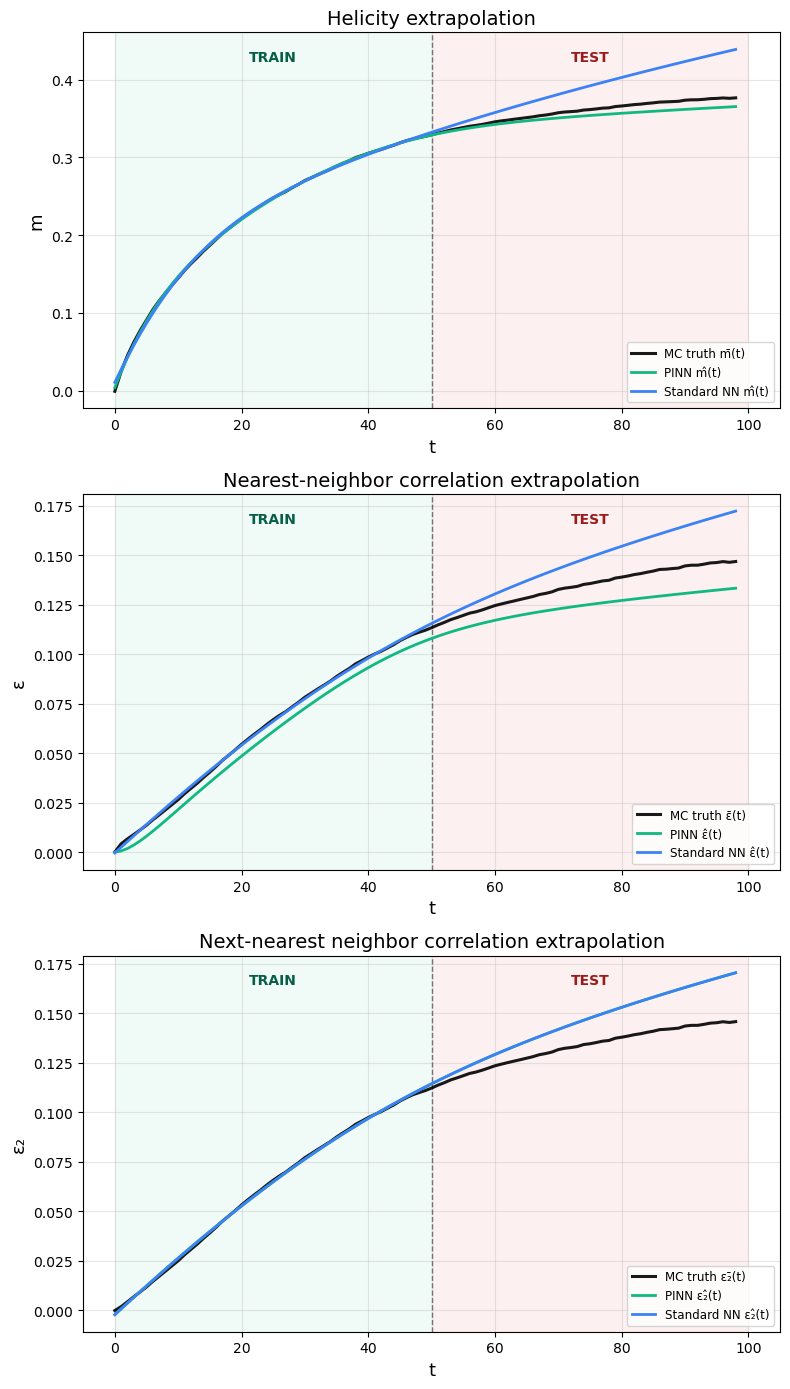

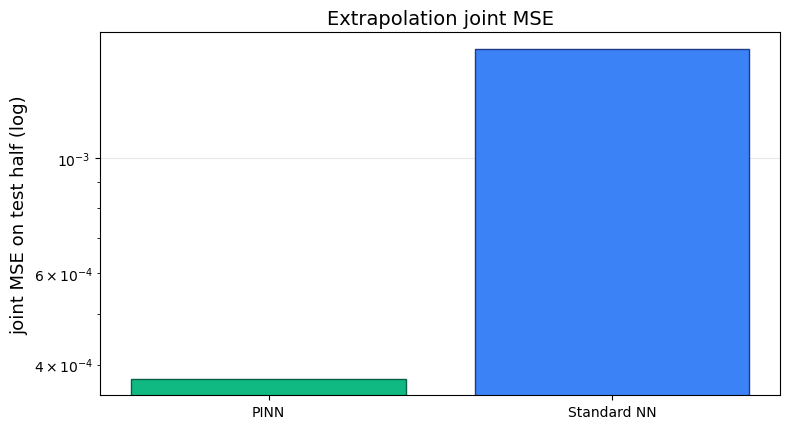

In [36]:
T_TRAIN = TOTAL_TIME / 2.0
mask_train = t_grid <  T_TRAIN
mask_test = t_grid >= T_TRAIN

t_train_np = t_grid[mask_train]
m_train_np = m_bar[mask_train]
eps_train_np = eps_bar[mask_train]
eps2_train_np = eps2_bar[mask_train]
print(f'Training half: {mask_train.sum()} points Test half: {mask_test.sum()} points')

EPOCHS_ADAM_X = 4000
LBFGS_STEPS_X = 300
N_COLLOC_X = 200

def train_pinn_m_extrap(t_data, m_data):
    torch.manual_seed(0)
    model = PINN_m().to(device)
    t_t  = torch.tensor(t_data, dtype=torch.float32, device=device).view(-1, 1)
    m_t  = torch.tensor(m_data, dtype=torch.float32, device=device).view(-1, 1)
    def physloss(t_c):
        m_c = model(t_c)
        m_dot = time_derivative(m_c, t_c)
        res = m_dot + (1.0 - model.a1) * m_c - 0.5 * model.a0 - 0.5 * model.a2 * m_c ** 2
        return torch.mean(res ** 2)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    for _ in range(EPOCHS_ADAM_X):
        opt.zero_grad()
        L_d = torch.mean((model(t_t) - m_t) ** 2)

        t_c = (torch.rand(N_COLLOC_X, 1, device=device) * TOTAL_TIME).requires_grad_(True)
        L_p = physloss(t_c)
        (L_d + L_p).backward(); opt.step()
    opt_l = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=25,
        history_size=100, line_search_fn='strong_wolfe',
        tolerance_grad=1e-12, tolerance_change=1e-15)
    t_c_fixed = torch.linspace(0.0, TOTAL_TIME, 2000, device=device).view(-1, 1)
    t_c_fixed.requires_grad_(True)
    def cl():
        opt_l.zero_grad()
        L_d = torch.mean((model(t_t) - m_t) ** 2)
        L_p = physloss(t_c_fixed)
        L = L_d + L_p
        L.backward()
        return L
    for _ in range(LBFGS_STEPS_X):
        opt_l.step(cl)
    return model

def train_curve_fit_extrap(model_class, t_data, target_data):
    torch.manual_seed(0)
    model = model_class().to(device)
    t_t = torch.tensor(t_data, dtype=torch.float32, device=device).view(-1, 1)
    y_t = torch.tensor(target_data, dtype=torch.float32, device=device).view(-1, 1)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    for _ in range(EPOCHS_ADAM_X):
        opt.zero_grad()
        L = torch.mean((model(t_t) - y_t) ** 2)
        L.backward(); opt.step()
    return model

m_x = train_pinn_m_extrap(t_train_np, m_train_np)
e2_x = train_curve_fit_extrap(PINN_eps2, t_train_np, eps2_train_np)
v_m_x = train_curve_fit_extrap(Standard_channel, t_train_np, m_train_np)
v_e_x = train_curve_fit_extrap(Standard_channel, t_train_np, eps_train_np)
v_e2_x = train_curve_fit_extrap(Standard_channel, t_train_np, eps2_train_np)

t_full = torch.tensor(t_grid, dtype=torch.float32, device=device).view(-1, 1)
with torch.no_grad():
    m_p_x = m_x(t_full).cpu().numpy().squeeze()
    e2_p_x = e2_x(t_full).cpu().numpy().squeeze()
    m_v_x = v_m_x(t_full).cpu().numpy().squeeze()
    e_v_x = v_e_x(t_full).cpu().numpy().squeeze()
    e2_v_x = v_e2_x(t_full).cpu().numpy().squeeze()

e_p_x = m_p_x ** 2

def mask_mse(arr, truth, mask):
    return float(((arr - truth)[mask] ** 2).mean())

fig, axes = plt.subplots(3, 1, figsize=(8, 14))
for ax, (truth, p_pred, v_pred, lbl, title) in zip(axes, [
    (m_bar, m_p_x,  m_v_x, 'm', 'Helicity extrapolation'),
    (eps_bar, e_p_x,  e_v_x, 'ε', 'Nearest-neighbor correlation extrapolation'),
    (eps2_bar, e2_p_x, e2_v_x, 'ε₂', 'Next-nearest neighbor correlation extrapolation'),
]):
    ax.axvspan(0, T_TRAIN, alpha=0.06, color='#10b981')
    ax.axvspan(T_TRAIN, TOTAL_TIME, alpha=0.08, color='#ef4444')
    ax.axvline(T_TRAIN, color='#1e293b', ls='--', lw=1, alpha=0.6)
    ax.plot(t_grid, truth, 'k-', lw=2.2, alpha=0.9, label=f'MC truth {lbl}̄(t)')
    ax.plot(t_grid, p_pred, color='#10b981', lw=2, label=f'PINN {lbl}̂(t)')
    ax.plot(t_grid, v_pred, color='#3b82f6', lw=2, ls='-', label=f'Standard NN {lbl}̂(t)')
    ymax = ax.get_ylim()[1]
    ax.text(T_TRAIN/2, ymax*0.92, 'TRAIN', ha='center', fontsize=10,
            color='#065f46', fontweight='bold')
    ax.text((T_TRAIN+TOTAL_TIME)/2, ymax*0.92, 'TEST', ha='center', fontsize=10,
            color='#991b1b', fontweight='bold')
    ax.set_xlabel('t'); ax.set_ylabel(lbl); ax.set_title(title)
    ax.legend(fontsize=8.5, loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(8, 4.4))
joint_p_te = sum(mask_mse(p, truth, mask_test) for p, truth in
                 [(m_p_x, m_bar), (e_p_x, eps_bar), (e2_p_x, eps2_bar)])
joint_v_te = sum(mask_mse(v, truth, mask_test) for v, truth in
                 [(m_v_x, m_bar), (e_v_x, eps_bar), (e2_v_x, eps2_bar)])
ax.bar(['PINN', 'Standard NN'], [joint_p_te, joint_v_te],
       color=['#10b981', '#3b82f6'], edgecolor=['#065f46', '#1e3a8a'])
ax.set_yscale('log'); ax.set_ylabel('joint MSE on test half (log)')
ax.set_title('Extrapolation joint MSE')
ax.set_axisbelow(True); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

In [37]:
CKPT_DIR = 'checkpoints_grid'
os.makedirs(CKPT_DIR, exist_ok=True)
torch.save(m_model.state_dict(), os.path.join(CKPT_DIR, 'pinn_perode_m.pt'))
torch.save(e2_model.state_dict(), os.path.join(CKPT_DIR, 'pinn_perode_eps2.pt'))
np.savez(os.path.join(CKPT_DIR, 'recovered_perode.npz'),
    a0_M=a0_M, a1_M=a1_M, a2_M=a2_M,
    a0_true=a0_true, a1_true=a1_true, a2_true=a2_true)
print(f'Saved PINN-m, PINN-ε₂, and recovered scalars to {CKPT_DIR}/')
print(f'PINN-m (a₀, a₁, a₂) = ({a0_M:+.4f}, {a1_M:+.4f}, {a2_M:+.4f})')

Saved PINN-m, PINN-ε₂, and recovered scalars to checkpoints_grid/
PINN-m (a₀, a₁, a₂) = (+0.0367, +0.9353, +0.0899)
